# 02 - Scheduler Simulation: 1,200 Jobs per Week

This notebook visualizes the controlled scheduler experiment that uses at most 1,200 submitted jobs from each available PM100 week. The cap keeps the simulated weekly samples comparable while the full-workload experiment is shown in the next notebook.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT / 'results' / 'scheduler_capped_1200'
print('Results directory:', RESULTS.relative_to(PROJECT))


Results directory: results\scheduler_capped_1200


## Reproduce This Run

```bash
python scripts/01_run_carbon_prediction.py --max-rows 60000
python scripts/02_run_scheduler.py --num-weeks 0 --max-jobs 1200 --split all --output-dir results/scheduler_capped_1200
```


In [2]:
metrics = pd.read_csv(RESULTS / 'scheduler_metrics.csv')
metrics


,policy,scheduled_jobs,skipped_jobs,total_actual_energy_kwh,total_actual_emissions_kg,total_predicted_emissions_kg,avg_wait_h,median_wait_h,p95_wait_h,avg_slowdown,max_processors_used,emissions_delta_vs_fcfs_kg,emissions_reduction_vs_fcfs_pct,avg_wait_delta_vs_fcfs_h
0,fcfs,12000.0,0.0,84836.381528,27364.660871,16187.101160,0.000000,0.000000,0.000000,1.000000,1452.0,0.000000,0.000000,0.000000
1,random,12000.0,0.0,84836.381528,27078.906180,15962.779118,11.744625,11.750139,22.758444,18.924428,761.0,-285.754691,1.044247,11.744625
2,carbon_aware,12000.0,0.0,84836.381528,25965.510150,15135.236288,12.360627,12.477917,20.146389,20.452392,8175.0,-1399.150720,5.112984,12.360627


In [3]:
weekly = pd.read_csv(RESULTS / 'scheduler_weekly_metrics.csv')
carbon_weekly = weekly[weekly['policy'].eq('carbon_aware')].copy()
summary = {
    'weeks': int(carbon_weekly['week_index'].nunique()),
    'carbon_aware_jobs': int(carbon_weekly['scheduled_jobs'].sum()),
    'weighted_reduction_pct': float(metrics.loc[metrics['policy'].eq('carbon_aware'), 'emissions_reduction_vs_fcfs_pct'].iloc[0]),
    'weekly_reduction_mean_pct': float(carbon_weekly['emissions_reduction_vs_fcfs_pct'].mean()),
    'weekly_reduction_min_pct': float(carbon_weekly['emissions_reduction_vs_fcfs_pct'].min()),
    'weekly_reduction_max_pct': float(carbon_weekly['emissions_reduction_vs_fcfs_pct'].max()),
}
pd.Series(summary).to_frame('value')


,value
weeks,10.000000
carbon_aware_jobs,12000.000000
weighted_reduction_pct,5.112984
weekly_reduction_mean_pct,7.464324
weekly_reduction_min_pct,3.067069
weekly_reduction_max_pct,14.405052


## Weekly Carbon-Aware Savings

The table below keeps the week-by-week comparison against FCFS visible. The last three rows are the final three simulated weeks.


In [4]:
savings = pd.read_csv(RESULTS / 'carbon_aware_weekly_savings.csv')
savings['week_start'] = pd.to_datetime(savings['week_start'])
savings.tail(3)


,week_index,week_start,fcfs_kg,carbon_aware_kg,saved_kg,reduction_pct
7,7,2020-06-22 00:00:00+00:00,4018.432777,3854.479260,163.953516,4.080036
8,8,2020-06-29 00:00:00+00:00,1015.459094,922.178829,93.280265,9.186019
9,9,2020-07-06 00:00:00+00:00,3601.584483,3385.967725,215.616758,5.986719


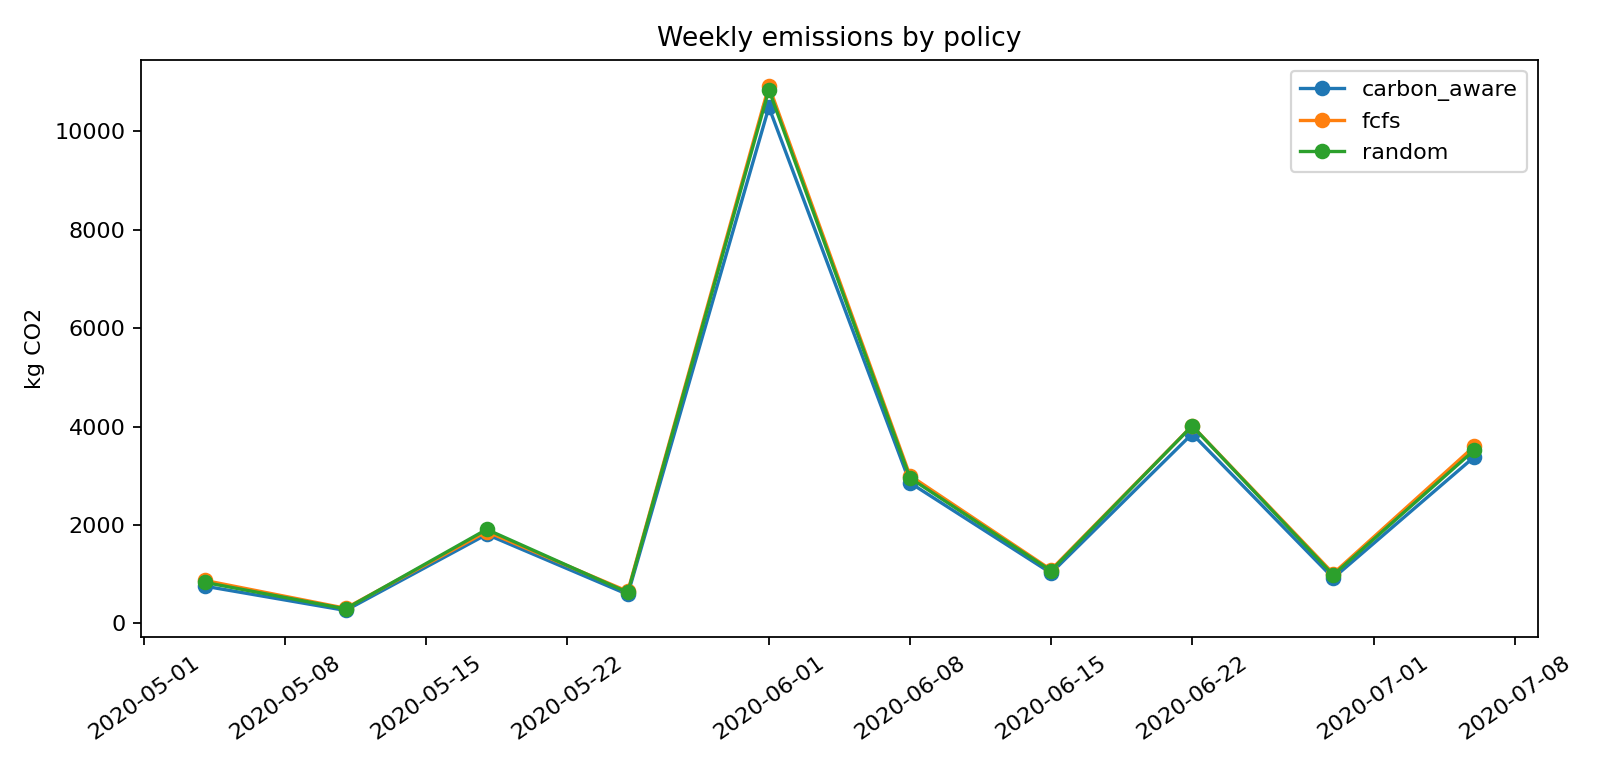

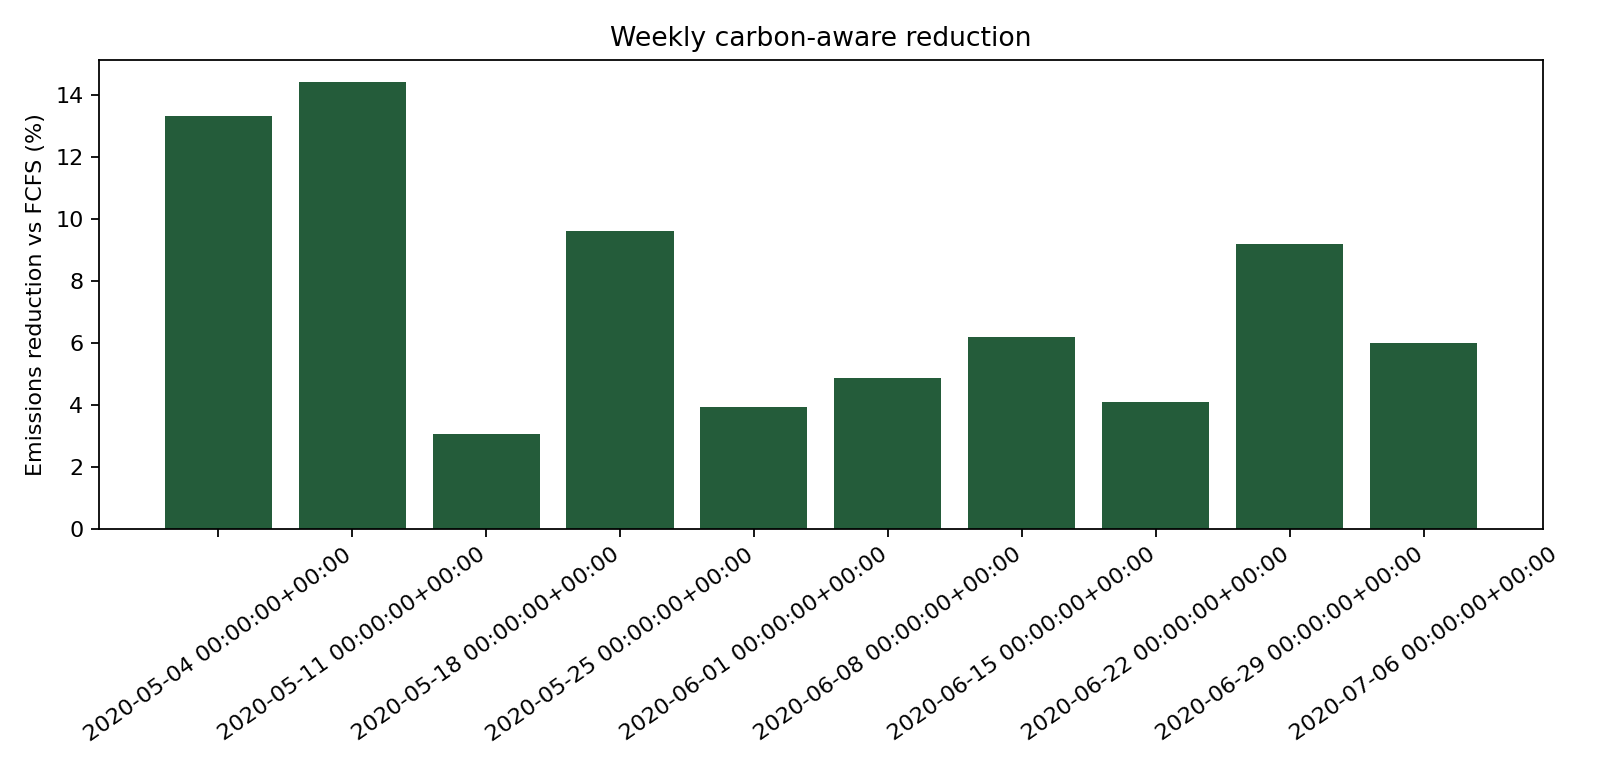

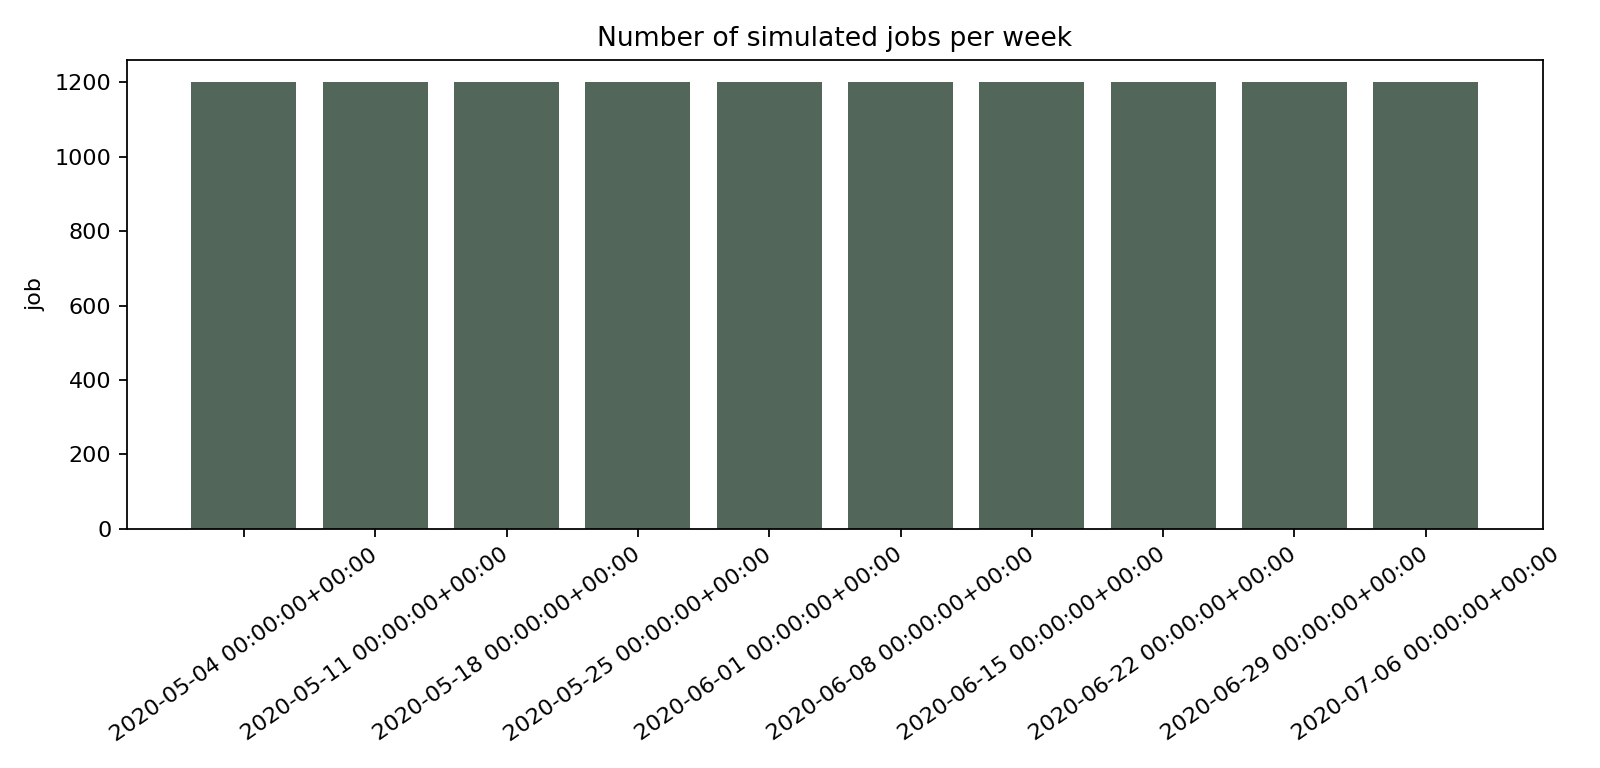

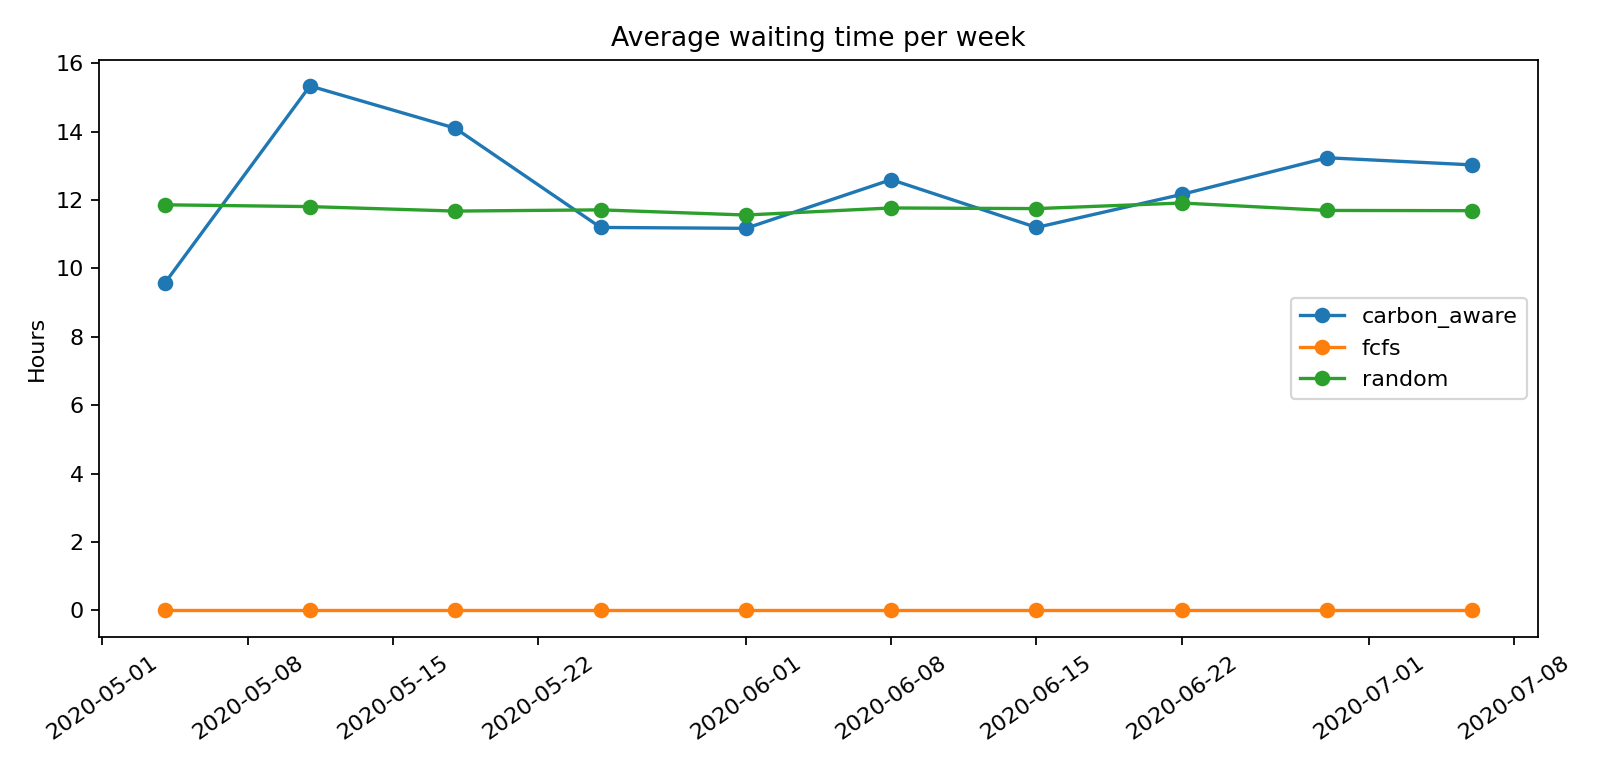

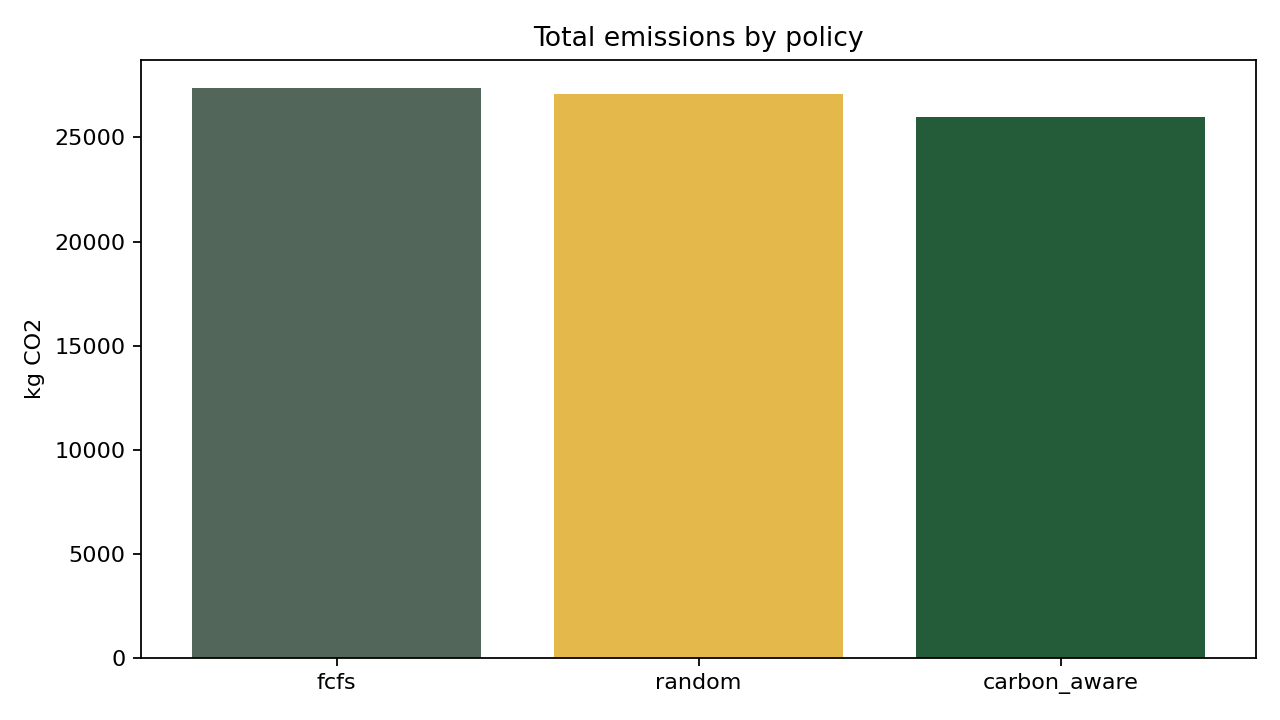

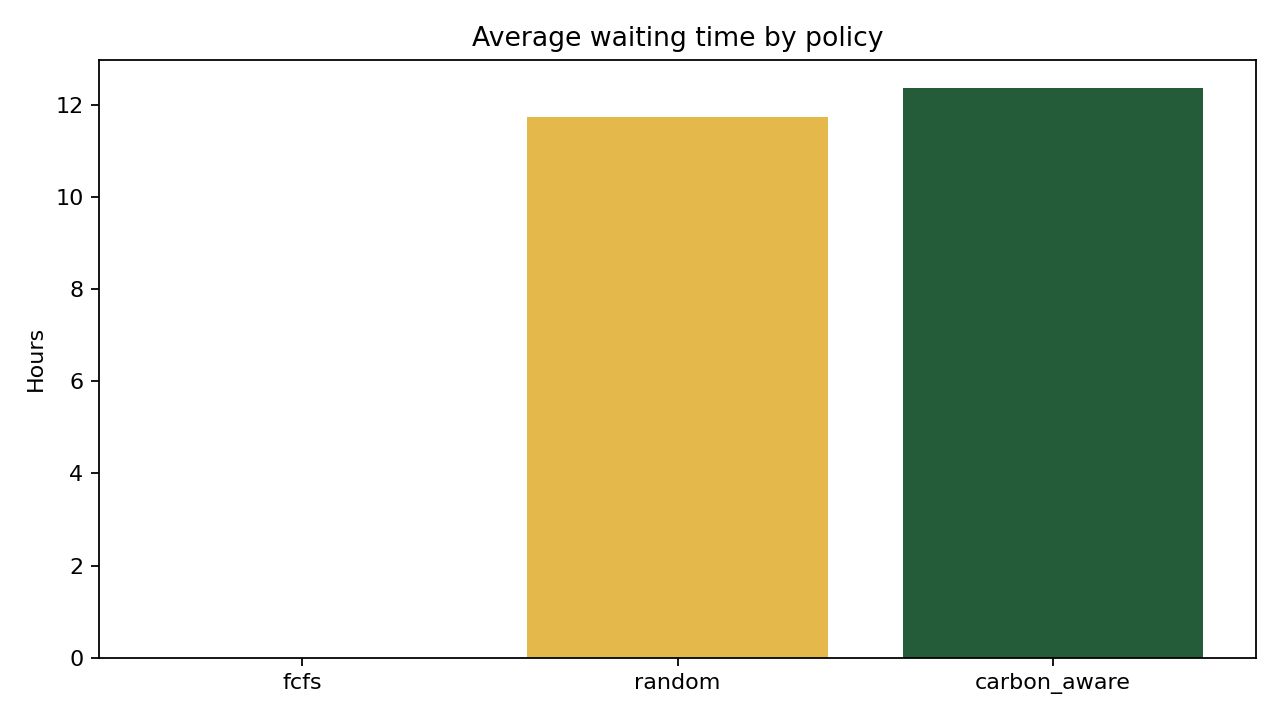

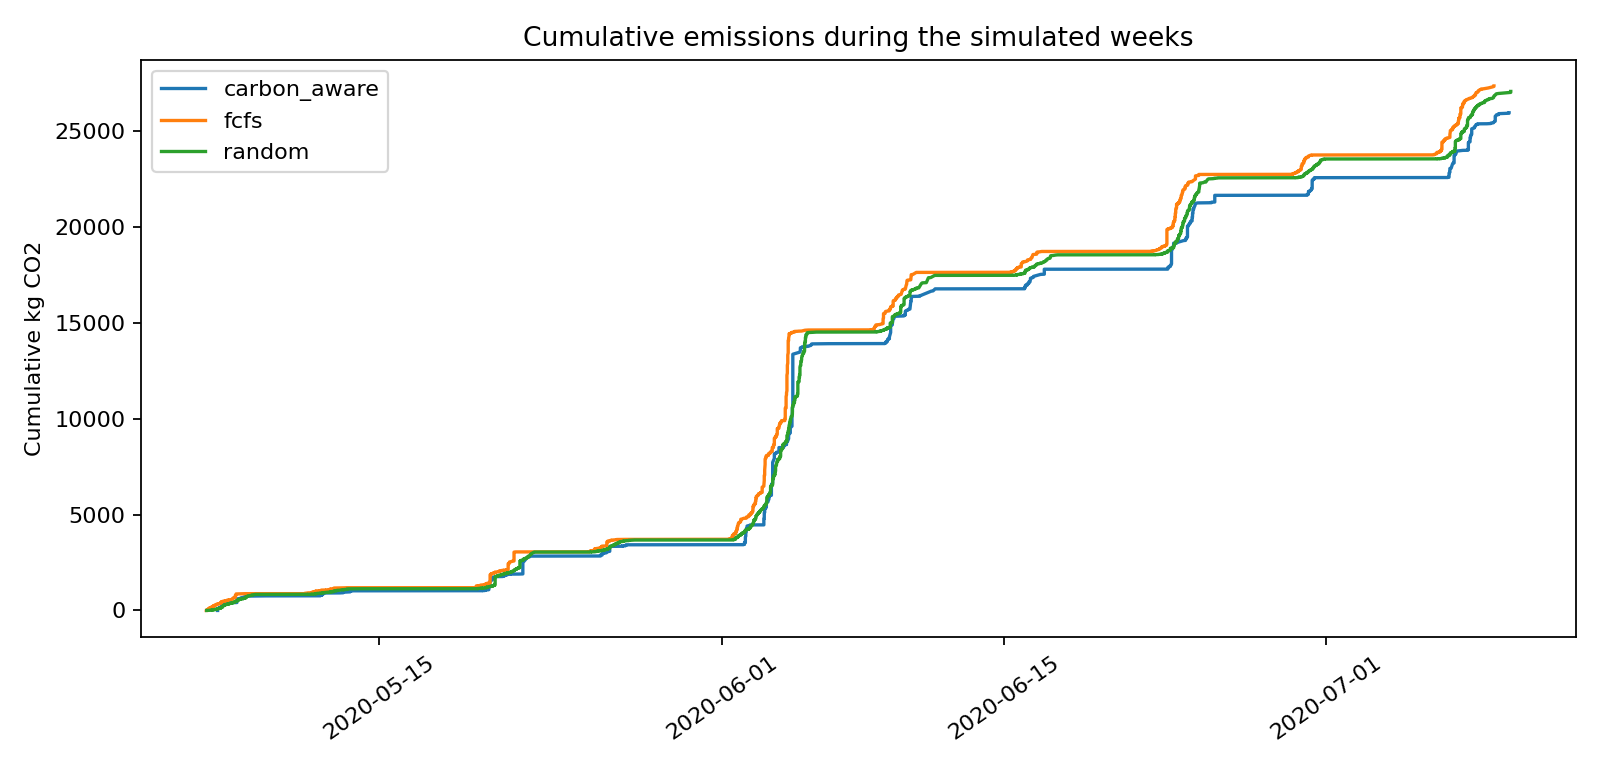

In [5]:
for name in [
    'scheduler_weekly_emissions.png',
    'scheduler_weekly_reduction_pct.png',
    'scheduler_weekly_jobs.png',
    'scheduler_weekly_wait.png',
    'scheduler_emissions_comparison.png',
    'scheduler_wait_comparison.png',
    'scheduler_cumulative_emissions.png',
]:
    display(Image(filename=str(RESULTS / name)))


## Interpretation

This capped run is a controlled comparison over the same maximum number of jobs per week. It is useful for visual weekly comparison, but it is not the complete weekly PM100 workload because weeks with more than 1,200 submitted jobs are truncated chronologically.
